**PRÁCTICA 3**

-Camila Montiel Zapata
-Luisa Fernanda Llamas

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio

In [27]:
def RMS_FUNC():
    RMS_V = np.sqrt((1/N)*np.mean(x_i**2))
    return RMS_V


In [28]:
signal = sio.loadmat('signals (1).mat')
senales = signal['ECG_filtered']
senal_fR = senales.flatten()
NC = len(senal_fR)
print(signal.keys())
print('el tamaño de la señal es:',senales.shape)

dict_keys(['__header__', '__version__', '__globals__', 'Fs', 'ECG_asRecording', 'ECG_filtered', 'EMG_filtered1', 'EMG_filtered2', 'EMG_asRecording1', 'EMG_asRecording2'])
el tamaño de la señal es: (1, 30720)


In [32]:
#Señales ECG Y EMG CRUDAS
senalECG = np.array(signal['ECG_asRecording'])
senal_fR = senalECG.flatten()
NC = len(senal_fR)

senalEMG1R = np.array(signal['EMG_asRecording1'])
senal_fEMG = senalEMG1R.flatten()
NEMG = len(senal_fEMG)  

senalEMG2R = np.array(signal['EMG_asRecording2'])
senal_fEMG2 = senalEMG2R.flatten()  
NEMG2 = len(senal_fEMG2)

#Señales ECG Y EMG FILTRADAS
senalECG_f = np.array(signal['ECG_filtered'])
senal_fECG = senalECG_f.flatten()


senalEMG1_f = signal['EMG_filtered1']
senal_fEMG1 = senalEMG1_f.flatten()
NEMG1 = len(senal_fEMG1)    

senal_fEMG2_f = signal['EMG_filtered2']
senal_fEMG2 = senal_fEMG2_f.flatten()       
NEMG2_f = len(senal_fEMG2)
print('la longitud de la señal es:', N )

la longitud de la señal es: 1


In [33]:
fs = 1
t_f1 = np.arange(NC)/fs
t_f2 = np.arange(NEMG1)/fs
tiempo_1 = (0,t_f1+fs, fs)
tiempo_2 = (0,t_f2+fs, fs)



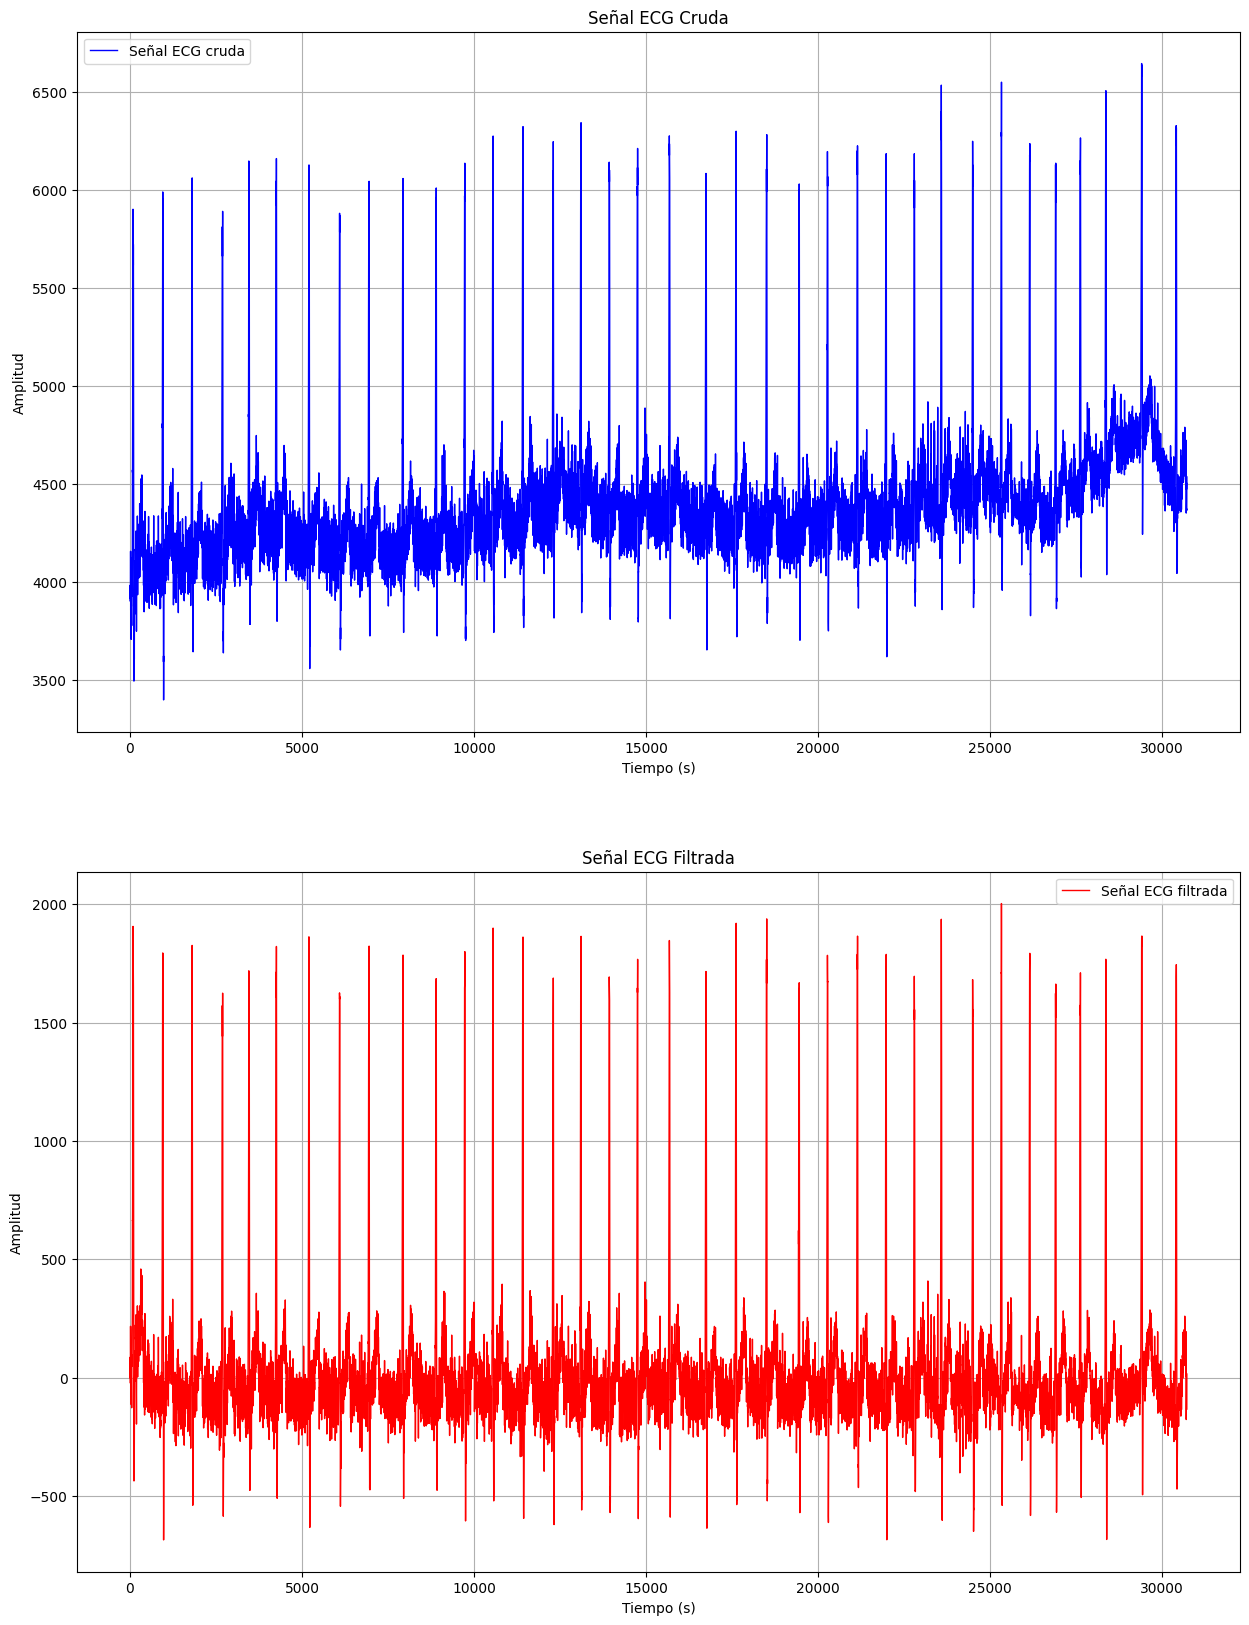

In [42]:
plt.figure(figsize=(15, 20))
plt.subplot(2, 1, 1)
plt.plot(t_f1, senal_fR, label='Señal ECG cruda', color='blue' , linewidth=1)
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.title('Señal ECG Cruda')
plt.legend()
plt.grid(True)
plt.subplot(2, 1, 2)
plt.plot(t_f1, senal_fECG, label='Señal ECG filtrada', color='red' , linewidth=1)   
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.title('Señal ECG Filtrada')
plt.legend()
plt.grid(True)

In [44]:
def filter_signal(signal, cutoff_freq, fs):
    from scipy.signal import butter, filtfilt
    nyquist = 0.5 * fs
    normal_cutoff = cutoff_freq / nyquist
    b, a = butter(4, normal_cutoff, btype='low', analog=False)
    filtered_signal = filtfilt(b, a, signal)
    return filtered_signal

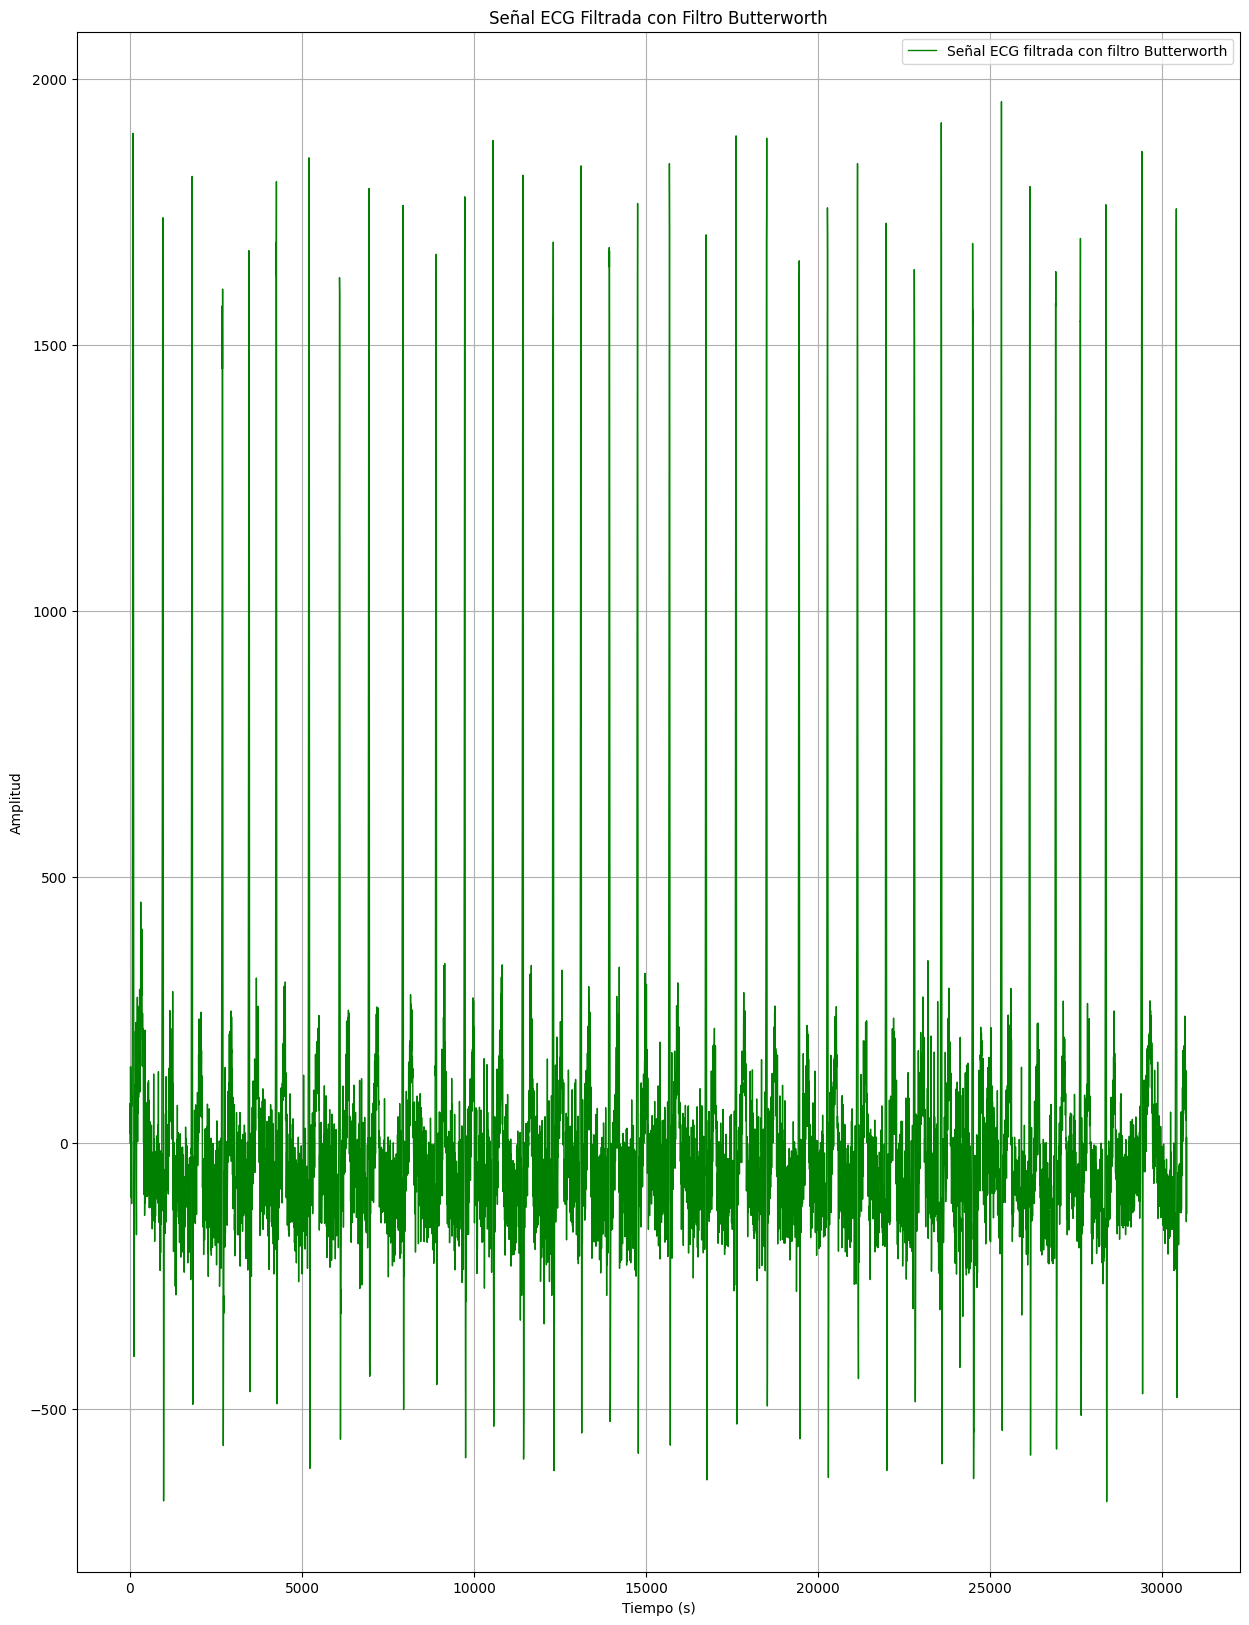

In [45]:
signal_ff = filter_signal(senal_fECG, cutoff_freq=0.1, fs=fs)
plt.figure(figsize=(15, 20))
plt.plot(t_f1, signal_ff, label='Señal ECG filtrada con filtro Butterworth', color='green' , linewidth=1)
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.title('Señal ECG Filtrada con Filtro Butterworth')
plt.legend()
plt.grid(True)